# Treinamento e Avaliação da Rede Neural Convolucional (BearingCNN)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT gerados a partir do dataset CWRU (4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar o treinamento da arquitetura `BearingCNN` através do módulo `src.cnn_processor`, restaurando automaticamente os pesos da época ótima (menor `val_loss`) para a avaliação no conjunto de teste.

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [16]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar módulos centralizados de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.cnn_processor import train_and_evaluate_bearing_cnn
from src.visualization import plot_training_curves


## 2. Execução do Treinamento com Checkpointing Automático

A função `train_and_evaluate_bearing_cnn` gerencia a fase de treino e validação, salva o checkpoint do menor `val_loss` e avalia o modelo no conjunto de teste inédito.

In [14]:
# Executar o pipeline de treinamento da BearingCNN em 1 linha
res = train_and_evaluate_bearing_cnn(num_epochs=NUM_EPOCHS, lr=LEARNING_RATE)


## 3. Curvas de Aprendizado (Perda e Acurácia)

In [12]:
hist = res['history']
epocas_eixo = range(1, len(hist['train_loss']) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(epocas_eixo, hist['train_loss'], label='Treino', marker='o')
axs[0].plot(epocas_eixo, hist['val_loss'], label='Validação', marker='s')
axs[0].set_title('Curva de Perda (Loss) - BearingCNN', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(epocas_eixo, hist['train_acc'], label='Treino', marker='o')
axs[1].plot(epocas_eixo, hist['val_acc'], label='Validação', marker='s')
axs[1].set_title('Curva de Acurácia (%) - BearingCNN', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acurácia (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

KeyError: 'history'

## 4. Relatório de Classificação Detalhado

In [ ]:
print('================================================================================')
print(' RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (BEARING CNN) ')
print('================================================================================')
print(classification_report(res['test_labels'], res['test_preds'], target_names=res['classes'], digits=4))

 RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (BEARING CNN) 
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



## 5. Matriz de Confusão

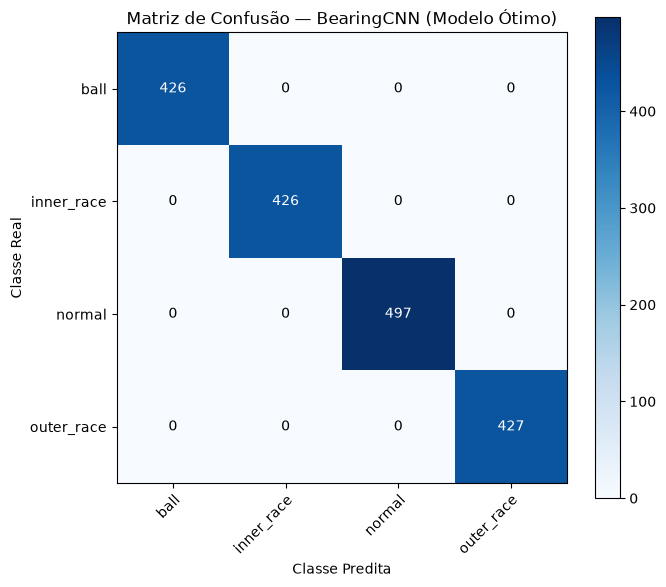

In [ ]:
cm = confusion_matrix(res['test_labels'], res['test_preds'])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=res['classes'], yticklabels=res['classes'],
       title='Matriz de Confusão — BearingCNN (Modelo Ótimo)',
       ylabel='Classe Real',
       xlabel='Classe Predita')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')

plt.tight_layout()
plt.show()